## Geometrical Analaysis (CME)
This notebook provides methods for analyizing geometry of the reconstructed CME buds. 

In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

sys.path.append('../../../utils')
from fonts.mpl_fonts import set_arial_font
set_arial_font()

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import math
import matplotlib.pyplot as plt
from flax.training import checkpoints

[mpl_fonts] Using font: Arial
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


In [76]:
## To reload

import importlib
import pinn.cme_analysis as cme_analysis
importlib.reload(cme_analysis)

<module 'pinn.cme_analysis' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/cme_analysis.py'>

### Compute neck ring of the bud geometry

In [5]:
# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
data_id = "jrc_cos7-1b"
shape = "bud-10"
step = 10000
phase = 2

N_voxel = 176
voxel_size = 4   # (nm)
half_length = N_voxel * voxel_size / 2.0

In [64]:
from pinn.cme_analysis import (
    extract_neck_band_geometry, extract_neck_ring_from_phase_field, 
    compute_ring_geometry_from_phase_field, save_ring_geom_to_vtk,
    extract_contour_stack_along_axis, save_contour_stack_to_vtk,
)

# ==== Parameters =====
gaussian_threshold = -0.00005


# for shape in ["bud-07", "bud-09", "bud-10", "bud-11", "bud-12"]:
for shape in ["bud-10"]:

    # ==== Load checkpoint data =====
    checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
    checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
    checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
    print(checkpoint_path)
    
    # ==== Extract neck plane based on vertex data =====
    npz_path = f"{checkpoint_dir}/verts_{step}_unit.npz"
    neck = extract_neck_band_geometry(
        npz_path,
        # percentile=5.0,
        gaussian_threshold = gaussian_threshold
    )
    
    print("threshold =", neck["threshold"])
    print("neck center =", neck["neck_center"])
    print("plane normal =", neck["plane_normal"])
    print("number of neck vertices =", len(neck["neck_indices"]))
    
    # ==== Extract neck ring as an intersect of neck plane and phi = 0 =====
    ring = extract_neck_ring_from_phase_field(
        checkpoint=checkpoint_data,
        neck_center=neck["neck_center"],
        plane_basis_u=neck["plane_basis_u"],
        plane_basis_v=neck["plane_basis_v"],
        neck_points=neck["neck_points"],
        half_length=half_length,
        margin_ratio=0.5,   # try 0.3 - 0.8
        grid_size=256,      # try 256 or 512
        level=0.0,
    )
    
    # ==== Calculate geometric quantities along the ring =====
    # ring_geom = compute_ring_geometry_from_phase_field(
    #     checkpoint=checkpoint_data,
    #     ring_3d=ring["ring_3d"],
    #     half_length=half_length,
    # )
    
    z_offsets = np.linspace(-100, 400, 51)
    
    stack = extract_contour_stack_along_axis(
        checkpoint=checkpoint_data,
        neck_center=neck["neck_center"],
        vertical_axis=neck["plane_normal"],
        # vertical_axis=-neck["plane_normal"],
        plane_basis_u=neck["plane_basis_u"],
        plane_basis_v=neck["plane_basis_v"],
        ref_points=ring["ring_3d"],  # neck ring is a good reference
        z_offsets=z_offsets,
        half_length=half_length,
        margin_ratio=1.5,
        grid_size=256,
        contour_resample_n=200,
    )
    
    
    # ==== Save data =====
    # npz_path = f"{checkpoint_dir}/ring_{shape}.npz"
    # np.savez(npz_path, **ring_geom)
    # vtk_path = f"{checkpoint_dir}/ring_{shape}.vtk"
    # save_ring_geom_to_vtk(ring_geom, filepath=vtk_path)
    
    
    npz_path = f"{checkpoint_dir}/stack_{shape}.npz"
    np.savez(npz_path, **stack)
    vtk_path = f"{checkpoint_dir}/stack_{shape}.vtk"
    save_contour_stack_to_vtk(stack, filepath=vtk_path, close_each_contour=True)


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/unscaled/bud-10/phase2_100000_1_100000_10/checkpoint_10000
threshold = -5e-05
neck center = [ 44.44722255 -64.43336907  13.64704859]
plane normal = [-0.31706576  0.92793667 -0.19596641]
number of neck vertices = 759
-0.99993074 0.9355398
ceter
Saved contour stack to: ../outputs/logs/jrc_cos7-1b/unscaled/bud-10/phase2_100000_1_100000_10/stack_bud-10.vtk


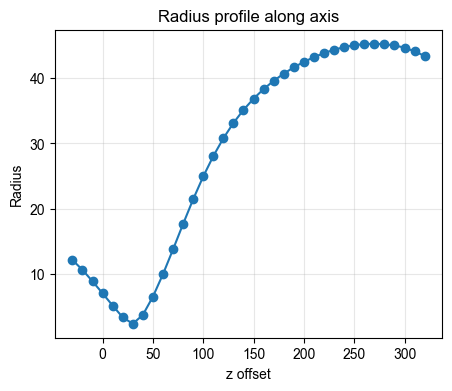

In [65]:
import numpy as np
import matplotlib.pyplot as plt


def plot_z_vs_radius(stack, use_equivalent=False, figsize=(5, 4), save_path=None):
    """
    Plot z_offset vs radius from contour stack.

    Parameters
    ----------
    stack : dict
        Output of extract_contour_stack_along_axis
    use_equivalent : bool, default=False
        If True, use area-based equivalent radius instead of fitted circle radius
    """
    z_list = []
    r_list = []

    for sl in stack["slices"]:
        if sl is None:
            continue

        z = sl["z_offset"]
        summary = sl["slice_summary"]
        # r = summary["fitted_radius"]
        r = summary["center_offset_from_axis"]        
        # r = summary["circularity"]

        z_list.append(z)
        r_list.append(r)

    z = np.array(z_list)
    r = np.array(r_list)

    # sort by z (important!)
    idx = np.argsort(z)
    z = z[idx]
    r = r[idx]

    plt.figure(figsize=figsize)
    plt.plot(z, r, "o-")
    plt.xlabel("z offset")
    plt.ylabel("Radius")
    plt.title("Radius profile along axis")
    plt.grid(alpha=0.3)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    return z, r

z, r = plot_z_vs_radius(stack)

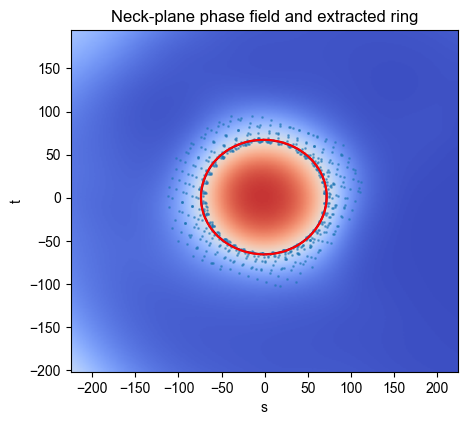

In [14]:
import matplotlib.pyplot as plt

phi_data = ring["phi_plane_data"]
phi_plane = phi_data["phi_plane"]
s_vals = phi_data["s_vals"]
t_vals = phi_data["t_vals"]
ring_st = ring["ring_st"]

plt.figure(figsize=(5, 5))
plt.imshow(
    phi_plane,
    origin="lower",
    extent=[s_vals.min(), s_vals.max(), t_vals.min(), t_vals.max()],
    aspect="equal",
    cmap="coolwarm",
    vmin=-1, vmax=1,
)
# plt.colorbar(label="phi")
plt.contour(
    phi_plane,
    levels=[0.0],
    origin="lower",
    extent=[s_vals.min(), s_vals.max(), t_vals.min(), t_vals.max()],
)
plt.plot(ring["neck_points_st"][:, 0], ring["neck_points_st"][:, 1], ".", ms=2, alpha=0.5)
plt.plot(ring_st[:, 0], ring_st[:, 1], "r-")
plt.xlabel("s")
plt.ylabel("t")
plt.title("Neck-plane phase field and extracted ring")
plt.show()

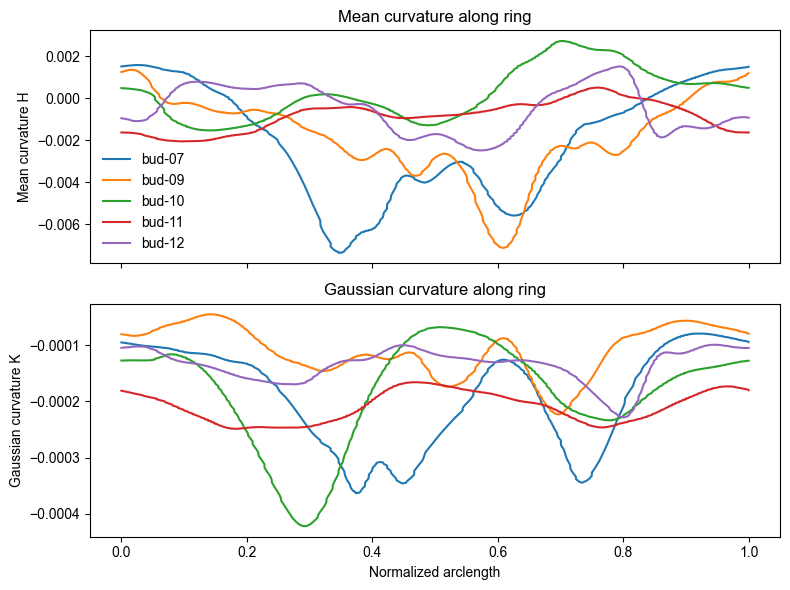

(<Figure size 800x600 with 2 Axes>,
 array([<Axes: title={'center': 'Mean curvature along ring'}, ylabel='Mean curvature H'>,
        <Axes: title={'center': 'Gaussian curvature along ring'}, xlabel='Normalized arclength', ylabel='Gaussian curvature K'>],
       dtype=object))

In [5]:
from pinn.cme_analysis import plot_ring_curvatures_multi

shape_list = ["bud-07", "bud-09", "bud-10", "bud-11", "bud-12"]

data_dict = {}
for shape in shape_list:
    checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
    npz_path = f"{checkpoint_dir}/ring_{shape}.npz"
    data_dict[shape] = np.load(npz_path)

plot_ring_curvatures_multi(
    data_dict,
    closed=True,
    normalize_arclength=True,   # often better for comparing different ring lengths
    smooth_window=7,
    figsize=(8, 6),
)

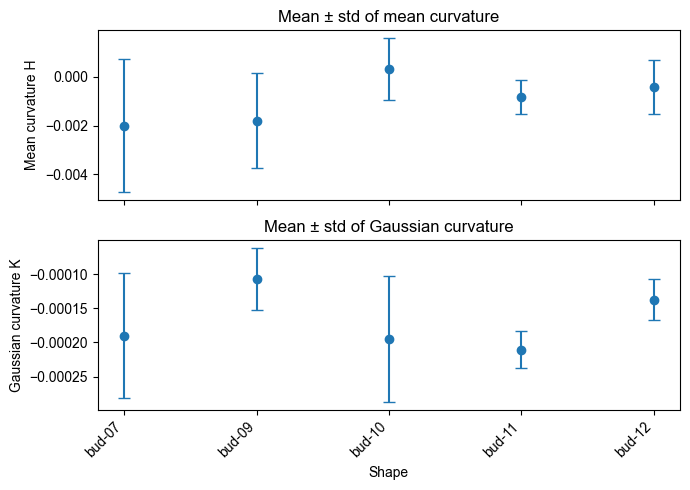

In [4]:
from pinn.cme_analysis import plot_ring_curvature_summary

shape_list = ["bud-07", "bud-09", "bud-10", "bud-11", "bud-12"]

data_dict = {}
for shape in shape_list:
    checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
    npz_path = f"{checkpoint_dir}/ring_{shape}.npz"
    data_dict[shape] = np.load(npz_path)

fig, axes, summary = plot_ring_curvature_summary(
    data_dict,
    shape_order=shape_list,
    figsize=(7, 5),
)

{'shape': 'bud-07', 'neck_radius': 81.2407622520496, 'max_fitted_radius': 108.93021291097028, 'radius_ratio': 1.3408319898946062, 'H_std': 0.002748176398520763, 'K_std': 9.135934203347712e-05}
{'shape': 'bud-09', 'neck_radius': 105.4692802033563, 'max_fitted_radius': 103.92877152143222, 'radius_ratio': 0.9853937688874541, 'H_std': 0.001954992111643378, 'K_std': 4.5424659071793374e-05}
{'shape': 'bud-10', 'neck_radius': 74.85356629477984, 'max_fitted_radius': 130.12257757775055, 'radius_ratio': 1.7383617644257128, 'H_std': 0.0012796757203394505, 'K_std': 9.250325573166781e-05}
{'shape': 'bud-11', 'neck_radius': 69.77459105829625, 'max_fitted_radius': 97.59316870088539, 'radius_ratio': 1.3986920914999972, 'H_std': 0.0007077332761817853, 'K_std': 2.695318432301929e-05}
{'shape': 'bud-12', 'neck_radius': 83.44739744451189, 'max_fitted_radius': 79.54899686852788, 'radius_ratio': 0.9532831376966999, 'H_std': 0.0011271046518211505, 'K_std': 3.038620677562583e-05}


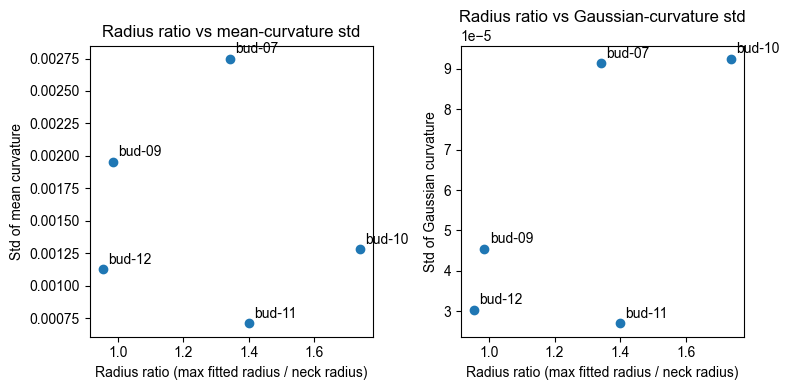

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': 'Radius ratio vs mean-curvature std'}, xlabel='Radius ratio (max fitted radius / neck radius)', ylabel='Std of mean curvature'>,
        <Axes: title={'center': 'Radius ratio vs Gaussian-curvature std'}, xlabel='Radius ratio (max fitted radius / neck radius)', ylabel='Std of Gaussian curvature'>],
       dtype=object))

In [77]:
from pinn.cme_analysis import summarize_shapes_radius_ratio_vs_curvature_std, plot_radius_ratio_vs_curvature_std

shape_list = ["bud-07", "bud-09", "bud-10", "bud-11", "bud-12"]

ring = {}
stack = {}

for shape in shape_list:
    checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
    ring[shape] = np.load(f"{checkpoint_dir}/ring_{shape}.npz", allow_pickle=True)
    stack_npz = np.load(f"{checkpoint_dir}/stack_{shape}.npz", allow_pickle=True)

    # If you saved the whole stack dict into one npz entry, use .item()
    if "stack" in stack_npz.files:
        stack[shape] = stack_npz["stack"].item()
    else:
        # if already expanded into fields, keep as-is
        stack[shape] = stack_npz

rows = summarize_shapes_radius_ratio_vs_curvature_std(
    shape_list=shape_list,
    ring_dict=ring,
    stack_dict=stack,
    curvature_source="ring",
)

for r in rows:
    print(r)

plot_radius_ratio_vs_curvature_std(rows)

{'shape': 'bud-07', 'max_center_offset': np.float64(31.70448524676722), 'H_std': 0.002748176398520763, 'K_std': 9.135934203347712e-05}
{'shape': 'bud-09', 'max_center_offset': np.float64(36.16545432703811), 'H_std': 0.001954992111643378, 'K_std': 4.5424659071793374e-05}
{'shape': 'bud-10', 'max_center_offset': np.float64(45.27687486329066), 'H_std': 0.0012796757203394505, 'K_std': 9.250325573166781e-05}
{'shape': 'bud-11', 'max_center_offset': np.float64(12.917650635630498), 'H_std': 0.0007077332761817853, 'K_std': 2.695318432301929e-05}
{'shape': 'bud-12', 'max_center_offset': np.float64(15.602502259394148), 'H_std': 0.0011271046518211505, 'K_std': 3.038620677562583e-05}


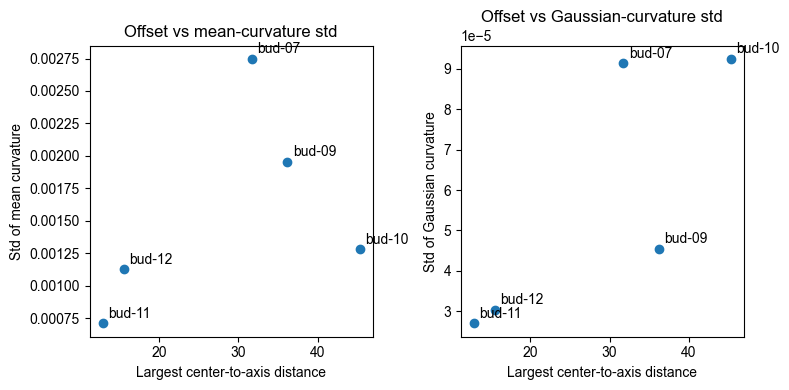

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': 'Offset vs mean-curvature std'}, xlabel='Largest center-to-axis distance', ylabel='Std of mean curvature'>,
        <Axes: title={'center': 'Offset vs Gaussian-curvature std'}, xlabel='Largest center-to-axis distance', ylabel='Std of Gaussian curvature'>],
       dtype=object))

In [75]:
from pinn.cme_analysis import summarize_shapes_offset_vs_curvature_std, plot_offset_vs_curvature_std

rows = summarize_shapes_offset_vs_curvature_std(
    shape_list=shape_list,
    ring_dict=ring,
    stack_dict=stack,
    curvature_source="ring",
)

for r in rows:
    print(r)

plot_offset_vs_curvature_std(rows)

In [6]:
shape_list = ["bud-07", "bud-09", "bud-10", "bud-11", "bud-12"]

ring = {}
stack = {}

for shape in shape_list:
    checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
    ring[shape] = np.load(f"{checkpoint_dir}/ring_{shape}.npz", allow_pickle=True)
    stack_npz = np.load(f"{checkpoint_dir}/stack_{shape}.npz", allow_pickle=True)
    stack[shape] = stack_npz 


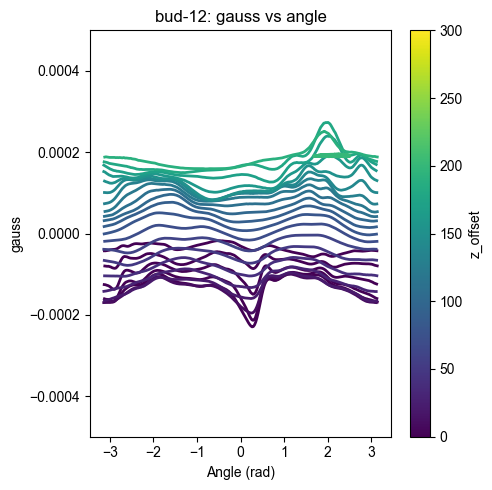

In [98]:
from pinn.cme_analysis import plot_contour_property_vs_angle

shape = "bud-12"
# plot_mean_curvature_vs_angle(stack[shape], shape=shape)

# plot_contour_property_vs_angle(
#     stack[shape],
#     shape=shape,
#     prop="mean_curvature", 
#     zmin=0, zmax=300, 
#     ylim=(-0.01, 0.02)
# )

plot_contour_property_vs_angle(
    stack[shape],
    shape=shape,
    prop="gauss", 
    zmin=0, zmax=300, 
    ylim=(-0.0005, 0.0005)
)

In [119]:
stack["bud-07"]

NpzFile '../outputs/logs/jrc_cos7-1b/unscaled/bud-07/phase2_100000_1_100000_10/stack_bud-07.npz' with keys: z_offsets, neck_center, vertical_axis, basis_u, basis_v...

In [121]:
for shape, npz in stack.items():
    print(f"\n=== {shape} ===")
    for key in npz.files:
        arr = npz[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")


=== bud-07 ===
z_offsets: shape=(41,), dtype=float64
neck_center: shape=(3,), dtype=float64
vertical_axis: shape=(3,), dtype=float64
basis_u: shape=(3,), dtype=float64
basis_v: shape=(3,), dtype=float64
slices: shape=(41,), dtype=object

=== bud-09 ===
z_offsets: shape=(41,), dtype=float64
neck_center: shape=(3,), dtype=float64
vertical_axis: shape=(3,), dtype=float64
basis_u: shape=(3,), dtype=float64
basis_v: shape=(3,), dtype=float64
slices: shape=(41,), dtype=object

=== bud-10 ===
z_offsets: shape=(51,), dtype=float64
neck_center: shape=(3,), dtype=float64
vertical_axis: shape=(3,), dtype=float64
basis_u: shape=(3,), dtype=float64
basis_v: shape=(3,), dtype=float64
slices: shape=(51,), dtype=object

=== bud-11 ===
z_offsets: shape=(41,), dtype=float64
neck_center: shape=(3,), dtype=float64
vertical_axis: shape=(3,), dtype=float64
basis_u: shape=(3,), dtype=float64
basis_v: shape=(3,), dtype=float64
slices: shape=(41,), dtype=object

=== bud-12 ===
z_offsets: shape=(41,), dtype=fl

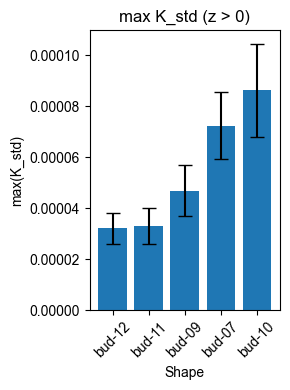

{'bud-12': np.float64(3.2133072150702166e-05),
 'bud-11': np.float64(3.299227246734752e-05),
 'bud-09': np.float64(4.6900551376804635e-05),
 'bud-07': np.float64(7.23461203295849e-05),
 'bud-10': np.float64(8.622011357226917e-05)}

In [22]:
from pinn.cme_analysis import plot_slice_summary_bar

shape_list = ["bud-12", "bud-11", "bud-09", "bud-07", "bud-10"]

# plot_slice_summary_bar(
#     stack,
#     var="fitted_radius",
#     reducer="max",
#     shape_list=shape_list,
#     only_positive_z=True,
# )

plot_slice_summary_bar(
    stack,
    var="K_std",
    reducer="max",
    shape_list=shape_list,
    only_positive_z=True,
)

In [127]:
stack["bud-07"]['slices'][10]['slice_summary']


{'contour_centroid_st': array([-4.80245862,  8.28414034]),
 'contour_centroid_3d': array([-15.09576939, -69.46758078,  39.76527809]),
 'fitted_circle_center_st': array([-4.80600877,  8.26378469]),
 'fitted_radius': 81.29808118065317,
 'circle_fit_residual_rms': 2.352428516228424,
 'area': np.float64(20725.948147252253),
 'perimeter': np.float64(511.51873049073),
 'equivalent_radius_area': np.float64(81.22360614872386),
 'equivalent_radius_perimeter': np.float64(81.41073444169068),
 'circularity': np.float64(0.9954081429068481),
 'axis_foot_3d': array([-11.09608506, -71.68963082,  31.35364276]),
 'center_offset_from_axis': np.float64(9.575520350505034),
 'slice_center_3d': array([-11.09608506, -71.68963082,  31.35364276]),
 'axis_direction': array([-0.13718147,  0.93964406, -0.313449  ]),
 'basis_u': array([-0.56754957, -0.33390935, -0.75259022]),
 'basis_v': array([-0.81183048,  0.07465641,  0.57910076]),
 'H_mean': -0.0019833556754747404,
 'H_std': 0.002721874870427493,
 'K_mean': -0.